In [416]:
import pandas as pd

# cargar aceleraciones
df_a = pd.read_csv("accel_ang2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estLinearAccelX": "ax",
    "inertial-6286.188861:estLinearAccelX:valid": "aXvalid",
    "inertial-6286.188861:estLinearAccelY": "ay",
    "inertial-6286.188861:estLinearAccelY:valid": "aYvalid",
    "inertial-6286.188861:estLinearAccelZ": "az",
    "inertial-6286.188861:estLinearAccelZ:valid": "aZvalid",
})

# quedarnos solo con datos válidos
df_a = df_a[
    (df_a["aXvalid"] == 1) &
    (df_a["aYvalid"] == 1) &
    (df_a["aZvalid"] == 1)
]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a["dt"] = df_a["Time"].diff() * 1e-9
# df_u

new_order = ['Time', 'ax', 'ay', 'az', 'dt']
df_a = df_a[new_order]

df_a

,Time,ax,ay,az,dt
0,1771622130451376384,0.003816,0.031436,0.061123,NaN
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753
...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509


In [417]:
import numpy as np


# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_a[col] = 0.0

p = np.zeros(3)
v = np.zeros(3)

# len(df_a)
for k in range(1, len(df_a)):

    dt = df_a.loc[k, "dt"]

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a = df_a.loc[k, ["ax", "ay", "az"]].values

    # Velocidad
    v = v + a * dt

    # Posición
    p = p + v * dt

    # Guardar en el DataFrame
    df_a.loc[k, ["vx", "vy", "vz"]] = v
    df_a.loc[k, ["px", "py", "pz"]] = p
    
df_a

,Time,ax,ay,az,dt,vx,vy,vz,px,py,pz
0,1771622130451376384,0.003816,0.031436,0.061123,NaN,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
1,1771622130461423872,0.005611,0.017711,0.056661,0.010047,0.000056,0.000178,0.000569,5.664810e-07,0.000002,0.000006
2,1771622130471371776,0.006301,0.036271,0.061147,0.009948,0.000119,0.000539,0.001178,1.750854e-06,0.000007,0.000017
3,1771622130481222400,0.004411,0.005835,0.034826,0.009851,0.000163,0.000596,0.001521,3.351648e-06,0.000013,0.000032
4,1771622130490975232,-0.007199,0.020422,0.042615,0.009753,0.000092,0.000795,0.001936,4.251768e-06,0.000021,0.000051
...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.004404,0.000184,0.032671,0.009791,0.141787,0.104645,1.220248,3.947801e+00,3.034907,18.024576
2864,1771622159090539008,-0.005789,0.007724,0.045007,0.009695,0.141731,0.104720,1.220685,3.949175e+00,3.035922,18.036410
2865,1771622159100142592,0.001703,0.001768,0.038660,0.009604,0.141747,0.104737,1.221056,3.950536e+00,3.036928,18.048137
2866,1771622159109651456,-0.007563,0.005440,0.046788,0.009509,0.141675,0.104789,1.221501,3.951883e+00,3.037924,18.059752


In [418]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_a["Time"] - df_a["Time"].iloc[0]) * 1e-9

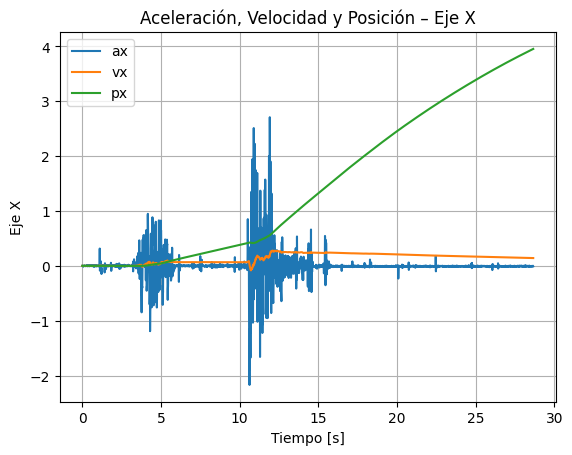

In [419]:
plt.figure()
plt.plot(t, df_a["ax"], label="ax")
plt.plot(t, df_a["vx"], label="vx")
plt.plot(t, df_a["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()


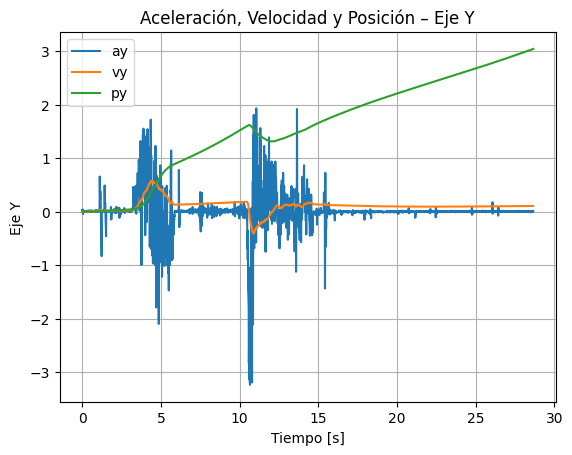

In [420]:
plt.figure()
plt.plot(t, df_a["ay"], label="ay")
plt.plot(t, df_a["vy"], label="vy")
plt.plot(t, df_a["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()


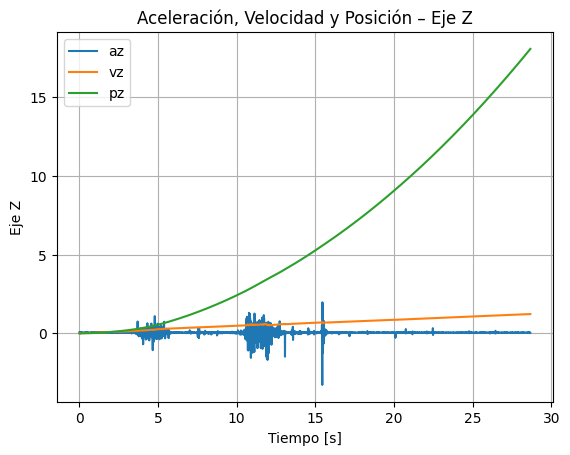

In [421]:
plt.figure()
plt.plot(t, df_a["az"], label="az")
plt.plot(t, df_a["vz"], label="vz")
plt.plot(t, df_a["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()


In [422]:
import pandas as pd

# cargar aceleraciones
df_a = pd.read_csv("accel_ang2.csv")

# renombrar columnas
df_a = df_a.rename(columns={
    "inertial-6286.188861:estAngularRateX": "arx",
    "inertial-6286.188861:estAngularRateX:valid": "arXvalid",
    "inertial-6286.188861:estAngularRateY": "ary",
    "inertial-6286.188861:estAngularRateY:valid": "arYvalid",
    "inertial-6286.188861:estAngularRateZ": "arz",
    "inertial-6286.188861:estAngularRateZ:valid": "alZvalid",
    "inertial-6286.188861:estLinearAccelX": "alx",
    "inertial-6286.188861:estLinearAccelX:valid": "alXvalid",
    "inertial-6286.188861:estLinearAccelY": "aly",
    "inertial-6286.188861:estLinearAccelY:valid": "alYvalid",
    "inertial-6286.188861:estLinearAccelZ": "alz",
    "inertial-6286.188861:estLinearAccelZ:valid": "alZvalid",
})

# quedarnos solo con datos válidos
# df_a = df_a[
#     (df_a["alXvalid"] == 1) &
#     (df_a["alYvalid"] == 1) &
#     (df_a["alZvalid"] == 1)
# ]

# df_a.drop(["aZvalid", "aYvalid", "aXvalid"], axis=1)

df_a["time_comp"] = df_a["Time"]*1e-8
df_a["time_comp"] = df_a["time_comp"].astype(int)
df_a["time_comp"] 

df_a["dt"] = df_a["Time"].diff() * 1e-9
# df_u

new_order = ['Time', 'arx', 'ary', 'arz', 'alx', 'aly', 'alz','dt']
df_a = df_a[new_order]

df_a

,Time,arx,ary,arz,alx,aly,alz,dt
0,1771622130451376384,0.001582,0.000654,-0.000164,0.003816,0.031436,0.061123,NaN
1,1771622130461423872,0.004586,-0.000865,0.000589,0.005611,0.017711,0.056661,0.010047
2,1771622130471371776,0.010129,-0.001447,-0.000128,0.006301,0.036271,0.061147,0.009948
3,1771622130481222400,0.013006,-0.000776,0.000311,0.004411,0.005835,0.034826,0.009851
4,1771622130490975232,0.010909,-0.000304,-0.000172,-0.007199,0.020422,0.042615,0.009753
...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.000142,0.000178,0.000437,-0.004404,0.000184,0.032671,0.009791
2864,1771622159090539008,0.000181,-0.000317,0.000668,-0.005789,0.007724,0.045007,0.009695
2865,1771622159100142592,0.000086,-0.000301,0.000165,0.001703,0.001768,0.038660,0.009604
2866,1771622159109651456,0.000002,0.001927,-0.000566,-0.007563,0.005440,0.046788,0.009509


In [423]:
# solo como comprobación

import numpy as np

dt = df_a['dt'].dropna().values
fs_est = 1 / np.mean(dt)

print("fs estimada:", fs_est, "Hz")

fs estimada: 100.00805612157812 Hz


In [424]:
# import pandas as pd

# # Cargar datos
# data = pd.read_csv("imu_data.csv")

# # Eliminar primera fila (dt = NaN)
# data = data.dropna().reset_index(drop=True)

arx = df_a['arx'].values
ary = df_a['ary'].values
arz = df_a['arz'].values
alx = df_a['alx'].values
aly = df_a['aly'].values
alz = df_a['alz'].values

ang_acc = np.vstack((arx, ary, arz, alx, aly, alz)).T

ang_acc

array([[ 1.58227643e-03,  6.54297997e-04, -1.64052122e-04,
         3.81580670e-03,  3.14364247e-02,  6.11232892e-02],
       [ 4.58560651e-03, -8.65241513e-04,  5.89051051e-04,
         5.61138848e-03,  1.77114215e-02,  5.66613488e-02],
       [ 1.01293838e-02, -1.44746655e-03, -1.27655570e-04,
         6.30054530e-03,  3.62712070e-02,  6.11470789e-02],
       ...,
       [ 8.59697102e-05, -3.00956221e-04,  1.65330130e-04,
         1.70348410e-03,  1.76788727e-03,  3.86596546e-02],
       [ 2.18554555e-06,  1.92726217e-03, -5.66411298e-04,
        -7.56250136e-03,  5.43988124e-03,  4.67879586e-02],
       [ 2.51541875e-04, -4.34103771e-04,  1.45477371e-03,
        -1.00328540e-02,  6.27174554e-03,  2.76207905e-02]],
      shape=(2868, 6))

In [425]:
import numpy as np
from scipy.signal import butter, sosfilt

fs = 100.0      # Hz
fc = 10.0       # Hz
order = 4

Wn = fc / (fs / 2)

sos = butter(order, Wn, btype='low', output='sos')
print(sos)

accel_filt = sosfilt(sos, ang_acc, axis=0)
accel_filt

[[ 0.00482434  0.00964869  0.00482434  1.         -1.04859958  0.29614036]
 [ 1.          2.          1.          1.         -1.32091343  0.63273879]]


array([[ 7.63344476e-06,  3.15655820e-06, -7.91443766e-07,
         1.84087617e-05,  1.51660107e-04,  2.94879734e-04],
       [ 7.07438660e-05,  1.59315163e-05, -2.19932684e-06,
         1.44326112e-04,  1.05144700e-03,  2.15159410e-03],
       [ 3.33123263e-04,  2.57050811e-05,  2.62267935e-06,
         5.48518561e-04,  3.56720693e-03,  7.57357004e-03],
       ...,
       [ 6.45275404e-04,  1.07392819e-04, -1.62225063e-04,
        -7.59428940e-03, -9.16705787e-04,  4.42353240e-02],
       [ 6.45936359e-04,  1.17048906e-04, -1.96731284e-04,
        -5.97103907e-03, -1.52544786e-03,  4.25313542e-02],
       [ 5.55254241e-04,  1.48896309e-04, -1.18133252e-04,
        -4.50689882e-03, -1.06683643e-03,  4.08037704e-02]],
      shape=(2868, 6))

In [426]:
from scipy.signal import butter, filtfilt

def butter_lowpass(fc, fs, order=4):
    wn = fc / (fs / 2)
    b, a = butter(order, wn, btype='low')
    return b, a

fc = 10  # Hz
b, a = butter_lowpass(fc, fs, order=4)

arx_f = filtfilt(b, a, arx)
ary_f = filtfilt(b, a, ary)
arz_f = filtfilt(b, a, arz)
alx_f = filtfilt(b, a, alx)
aly_f = filtfilt(b, a, aly)
alz_f = filtfilt(b, a, alz)
arx_f

array([0.00159218, 0.00479533, 0.00723775, ..., 0.00029536, 0.00026163,
       0.00025063], shape=(2868,))

In [427]:
arx

array([1.58227643e-03, 4.58560651e-03, 1.01293838e-02, ...,
       8.59697102e-05, 2.18554555e-06, 2.51541875e-04], shape=(2868,))

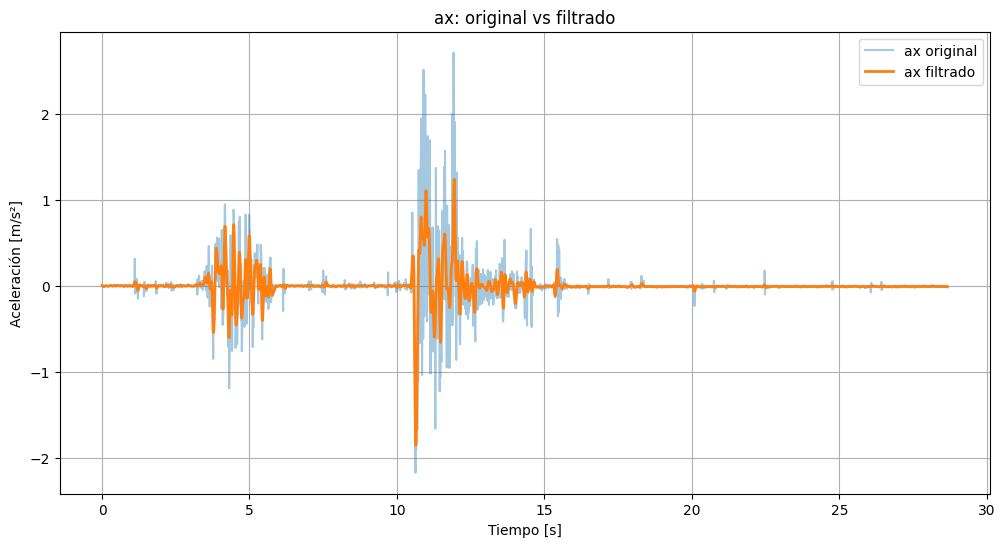

In [428]:
import matplotlib.pyplot as plt

# t = np.cumsum(dt)
N = len(alx)
t = np.arange(N) / fs

plt.figure(figsize=(12,6))
plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, alx_f, label='ax filtrado', linewidth=2)
plt.xlabel("Tiempo [s]")
plt.ylabel("Aceleración [m/s²]")
plt.title("ax: original vs filtrado")
plt.legend()
plt.grid()
plt.show()

In [429]:
print(arx_f.shape)
df_a['arx']

(2868,)


0       0.001582
1       0.004586
2       0.010129
3       0.013006
4       0.010909
          ...   
2863   -0.000142
2864    0.000181
2865    0.000086
2866    0.000002
2867    0.000252
Name: arx, Length: 2868, dtype: float64

In [430]:
df_a['arx_f'] = arx_f
df_a['ary_f'] = ary_f
df_a['arz_f'] = arz_f
df_a['alx_f'] = alx_f
df_a['aly_f'] = aly_f
df_a['alz_f'] = alz_f
df_a

,Time,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f
0,1771622130451376384,0.001582,0.000654,-0.000164,0.003816,0.031436,0.061123,NaN,0.001592,0.000667,-0.000169,0.003866,0.031384,0.061156
1,1771622130461423872,0.004586,-0.000865,0.000589,0.005611,0.017711,0.056661,0.010047,0.004795,0.000100,-0.000104,0.002268,0.023262,0.052669
2,1771622130471371776,0.010129,-0.001447,-0.000128,0.006301,0.036271,0.061147,0.009948,0.007238,-0.000362,-0.000063,0.000430,0.015257,0.044974
3,1771622130481222400,0.013006,-0.000776,0.000311,0.004411,0.005835,0.034826,0.009851,0.008402,-0.000644,-0.000057,-0.001685,0.007712,0.038827
4,1771622130490975232,0.010909,-0.000304,-0.000172,-0.007199,0.020422,0.042615,0.009753,0.008161,-0.000726,-0.000080,-0.003858,0.001283,0.034791
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.000142,0.000178,0.000437,-0.004404,0.000184,0.032671,0.009791,0.000446,0.000282,-0.000171,-0.003642,-0.000371,0.042063
2864,1771622159090539008,0.000181,-0.000317,0.000668,-0.005789,0.007724,0.045007,0.009695,0.000360,0.000232,0.000064,-0.003734,0.000866,0.039686
2865,1771622159100142592,0.000086,-0.000301,0.000165,0.001703,0.001768,0.038660,0.009604,0.000295,0.000091,0.000436,-0.004974,0.002498,0.036376
2866,1771622159109651456,0.000002,0.001927,-0.000566,-0.007563,0.005440,0.046788,0.009509,0.000262,-0.000137,0.000916,-0.007207,0.004343,0.032213


In [431]:
import numpy as np

# Inicializar columnas
for col in ["vx", "vy", "vz", "px", "py", "pz"]:
    df_a[col] = 0.0

p = np.zeros(3)
v = np.ones(3)

# Umbrales
ACC_TH = 0.1       # m/s^2
GYRO_TH = np.deg2rad(1.0)  # rad/s

print(v.shape)
print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
# len(df_a)

a = df_a.loc[2, ["alx", "aly", "alz"]].values
a.shape

v.shape
dt = 0.01
# np.zeros(3).shape

a = df_a.loc[2, ["alx", "aly", "alz"]].values
print(a, a.shape)

print(v, v.shape)

x = v + a#*dt
x

(3,)
(3,)
[0.00630055 0.03627121 0.06114708] (3,)
[1. 1. 1.] (3,)


array([1.00630055, 1.03627121, 1.06114708])

In [432]:
# a = df_a.loc[3, ["alx", "aly", "alz"]].values
# a

In [433]:
# def zupt_acc_ang(a, g, v):
#     if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
#         v = np.zeros(3)   # ZUPT duro

In [434]:
# ACC_TH_ENERGY = (0.02**2)*3 # = 0.0012

In [435]:
for k in range(0, len(df_a)):

    # dt = df_a.loc[k, "dt"]
    dt = 0.01

    # Si el primer dt es NaN, lo saltamos
    if pd.isna(dt):
        continue

    a = df_a.loc[k, ["arx_f", "aly_f", "alz_f"]].values
    g = df_a.loc[k, ["arx_f", "ary_f", "arz_f"]].values

    # Velocidad
    v = v + a * dt

    # Posición
    p = p + v * dt

    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
    
    
    # Detección ZUPT
    
    # Caso A
    # if np.linalg.norm(acc[k]) < ACC_TH and np.linalg.norm(gyro[k]) < GYRO_TH:
    
    if np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH:
        v = np.zeros(3)   # ZUPT duro

    zupt = (np.linalg.norm(a) < ACC_TH and np.linalg.norm(g) < GYRO_TH)

    # if zupt:
    #     # eje principal de movimiento
    #     v[1] = 0.0   # Y duro

    #     # ejes no excitados → corrección más agresiva
    #     if abs(v[0]) < 0.02:
    #         v[0] = 0.0
    #     if abs(v[2]) < 0.02:
    #         v[2] = 0.0

    # E = np.mean(np.sum(a_window**2, axis=1))
    # if E < ACC_TH_ENERGY:
    #     v = np.zeros(3)

    # Guardar en el DataFrame
    # print(df_a.loc[k, ["vx", "vy", "vz"]].shape)
    df_a.loc[k, ["vx", "vy", "vz"]] = v
    df_a.loc[k, ["px", "py", "pz"]] = p
    
df_a

,Time,arx,ary,arz,alx,aly,alz,dt,arx_f,ary_f,arz_f,alx_f,aly_f,alz_f,vx,vy,vz,px,py,pz
0,1771622130451376384,0.001582,0.000654,-0.000164,0.003816,0.031436,0.061123,NaN,0.001592,0.000667,-0.000169,0.003866,0.031384,0.061156,0.0,0.0,0.0,0.010000,0.010003,0.010006
1,1771622130461423872,0.004586,-0.000865,0.000589,0.005611,0.017711,0.056661,0.010047,0.004795,0.000100,-0.000104,0.002268,0.023262,0.052669,0.0,0.0,0.0,0.010001,0.010005,0.010011
2,1771622130471371776,0.010129,-0.001447,-0.000128,0.006301,0.036271,0.061147,0.009948,0.007238,-0.000362,-0.000063,0.000430,0.015257,0.044974,0.0,0.0,0.0,0.010001,0.010007,0.010016
3,1771622130481222400,0.013006,-0.000776,0.000311,0.004411,0.005835,0.034826,0.009851,0.008402,-0.000644,-0.000057,-0.001685,0.007712,0.038827,0.0,0.0,0.0,0.010002,0.010008,0.010020
4,1771622130490975232,0.010909,-0.000304,-0.000172,-0.007199,0.020422,0.042615,0.009753,0.008161,-0.000726,-0.000080,-0.003858,0.001283,0.034791,0.0,0.0,0.0,0.010003,0.010008,0.010023
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2863,1771622159080844032,-0.000142,0.000178,0.000437,-0.004404,0.000184,0.032671,0.009791,0.000446,0.000282,-0.000171,-0.003642,-0.000371,0.042063,0.0,0.0,0.0,-0.017721,0.093799,0.490380
2864,1771622159090539008,0.000181,-0.000317,0.000668,-0.005789,0.007724,0.045007,0.009695,0.000360,0.000232,0.000064,-0.003734,0.000866,0.039686,0.0,0.0,0.0,-0.017721,0.093799,0.490384
2865,1771622159100142592,0.000086,-0.000301,0.000165,0.001703,0.001768,0.038660,0.009604,0.000295,0.000091,0.000436,-0.004974,0.002498,0.036376,0.0,0.0,0.0,-0.017721,0.093800,0.490387
2866,1771622159109651456,0.000002,0.001927,-0.000566,-0.007563,0.005440,0.046788,0.009509,0.000262,-0.000137,0.000916,-0.007207,0.004343,0.032213,0.0,0.0,0.0,-0.017721,0.093800,0.490390


In [436]:
import matplotlib.pyplot as plt

# Tiempo relativo en segundos
t = (df_a["Time"] - df_a["Time"].iloc[0]) * 1e-9

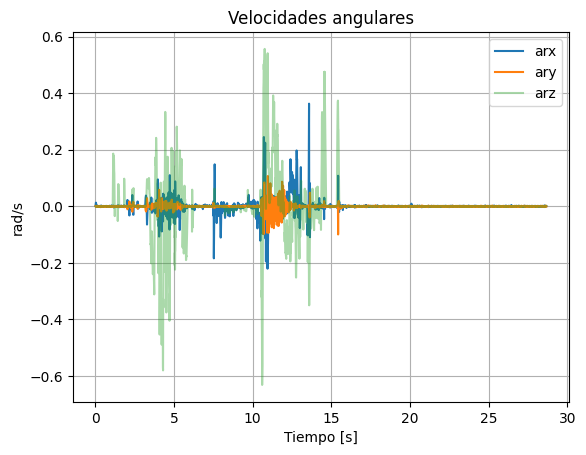

array([0.00159218, 0.00479533, 0.00723775, ..., 0.00029536, 0.00026163,
       0.00025063], shape=(2868,))

In [437]:
plt.figure()
plt.plot(t, df_a["arx"], label="arx")
plt.plot(t, df_a["ary"], label="ary")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_a["arz"], label="arz", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares")
plt.show()

arx_f	

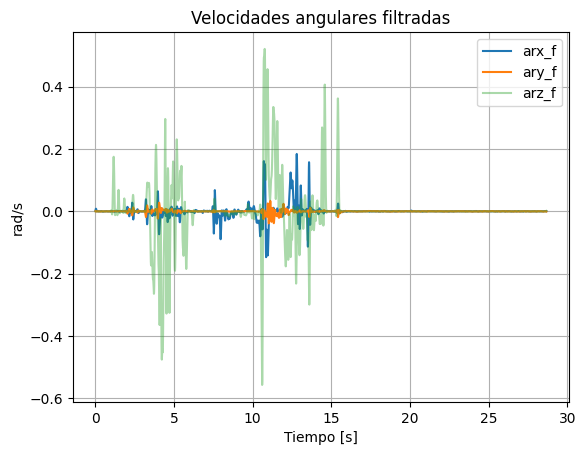

In [438]:
plt.figure()
plt.plot(t, df_a["arx_f"], label="arx_f")
plt.plot(t, df_a["ary_f"], label="ary_f")
# plt.plot(t, alx, label='ax original', alpha=0.4)
plt.plot(t, df_a["arz_f"], label="arz_f", alpha=0.4)
plt.xlabel("Tiempo [s]")
plt.ylabel("rad/s")
plt.legend()
plt.grid(True)
plt.title("Velocidades angulares filtradas")
plt.show()

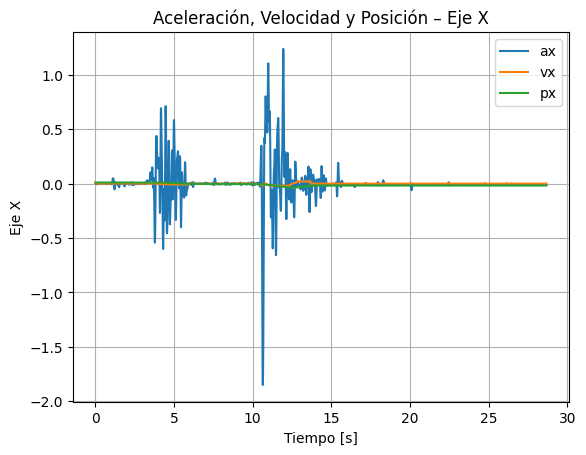

In [439]:
plt.figure()
plt.plot(t, df_a["alx_f"], label="ax")
plt.plot(t, df_a["vx"], label="vx")
plt.plot(t, df_a["px"], label="px")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje X")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje X")
plt.show()

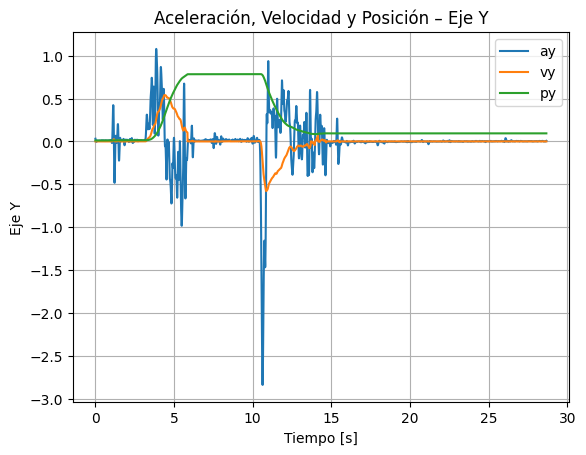

In [440]:
plt.figure()
plt.plot(t, df_a["aly_f"], label="ay")
plt.plot(t, df_a["vy"], label="vy")
plt.plot(t, df_a["py"], label="py")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Y")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Y")
plt.show()

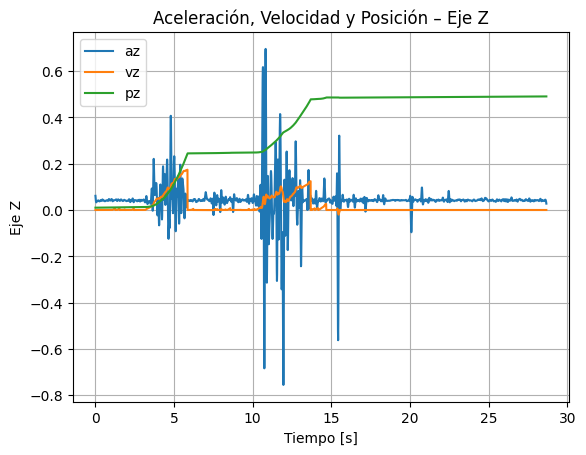

In [441]:
plt.figure()
plt.plot(t, df_a["alz_f"], label="az")
plt.plot(t, df_a["vz"], label="vz")
plt.plot(t, df_a["pz"], label="pz")
plt.xlabel("Tiempo [s]")
plt.ylabel("Eje Z")
plt.legend()
plt.grid(True)
plt.title("Aceleración, Velocidad y Posición – Eje Z")
plt.show()

In [442]:
a = df_a.loc[5, ["alx", "aly", "alz"]].values
norm = np.linalg.norm(a)
a_norm = a / np.linalg.norm(a)
print(a)
print(norm)
print(a_norm)
print(a[0], abs(a[0]))

[-0.0125104  -0.0444557  -0.01304731]
0.04799012384711922
[-0.26068698 -0.92635109 -0.27187491]
-0.0125104002654552 0.0125104002654552


In [443]:
# # ZUPT parcial

# EPS_ACCEL = 0.1      # m/s^2
# VAR_ACCEL = 0.02     # (m/s^2)^2
# MIN_SAMPLES = int(1.0 * fs)

# zupt = np.zeros(len(accel_filt), dtype=bool)
# counter = 0

# for k in range(N, len(accel_filt)):
#     acc_win = accel_filt[k-N:k]
    
#     acc_var = np.mean(np.var(acc_win, axis=0))
#     acc_dev = abs(acc_norm[k] - g)

#     stationary = (
#         acc_dev < EPS_ACCEL and
#         acc_var < VAR_ACCEL
#     )

#     if stationary:
#         counter += 1
#         if counter >= MIN_SAMPLES:
#             zupt[k] = True
#     else:
#         counter = 0

In [444]:
# # magnitud total del ZUPT

# acc_mag = np.sqrt(ax**2 + ay**2 + az**2)
# acc_mag_f = np.sqrt(ax_f**2 + ay_f**2 + az_f**2)

# plt.figure(figsize=(12,6))
# plt.plot(t, acc_mag, label='|a| original', alpha=0.4)
# plt.plot(t, acc_mag_f, label='|a| filtrado', linewidth=2)
# plt.axhline(9.81, color='k', linestyle='--', label='g')
# plt.legend()
# plt.grid()
# plt.title("Magnitud de aceleración")
# plt.show()

In [445]:
# Diseño de umbrales para ZUPT (criterio práctico)

# ZUPT no se diseña “a ojo”, se basa en:

# Aceleración cerca de g

# Baja varianza

# Giroscopio bajo (si lo tienes)

# Umbrales típicos (100 Hz)
# Variable	Umbral típico
# |a| − g	< 0.05 – 0.15 m/s²
# σ(a) ventana	< 0.02 – 0.05 m/s²
# |ω|	< 0.5 – 2 deg/s
# Ventana	0.2 – 0.5 s

In [446]:
# Eso es ingeniería bien hecha:

# FFT → identificar banda útil

# Allan → ruido y bias

# Datos reales → ajustar fc y umbrales

In [447]:
# from scipy.signal import sosfilt

# # gyro_filt = sosfilt(sos, gyro_raw)
# accel_filt = sosfilt(sos, accel_raw)

In [448]:
# from scipy.signal import sosfiltfilt

# gyro_filt = sosfiltfilt(sos, gyro_raw)